# 🧪 Gemastik 2026: Pretrained Base Model Zero-Shot Multimodal Evaluation
### 🔍 Zero-Shot Inference with Corrected Pretrained `id2label` Mapping

This notebook evaluates the **raw pretrained base models** out-of-the-box (zero-shot, without fine-tuning) on the Indonesian video dataset (`kfold_splits.json` (Fold 1)):
1. 📹 **Video Base Model:** `dima806/deepfake_vs_real_image_detection` (Vision Transformer - ViT)
2. 🎙️ **Audio Base Model:** `MelodyMachine/Deepfake-audio-detection-V2` (Wav2Vec2)
3. 🤝 **Raw Multimodal Ensemble:** Late fusion of un-finetuned visual and acoustic models ($0.5 \cdot P_{\text{video}} + 0.5 \cdot P_{\text{audio}}$)

---
### ⚠️ Critical `id2label` Alignment Notice
- **Video Model (`dima806`):** HuggingFace config `id2label` = `{"0": "Real", "1": "Fake"}` $\rightarrow$ Matches dataset (`0 = Real, 1 = AI`).
- **Audio Model (`MelodyMachine`):** HuggingFace config `id2label` = `{"0": "fake", "1": "real"}` but **empirically the base head outputs `[Real, AI]` at indices `[0, 1]`** (verified on fold-1 val: swapping produced inverted 34.58% vs expected ~66%).
- **Mapping used (empirical):** index `0` (declared "fake") behaves as **Real**, index `1` (declared "real") behaves as **AI** → **no column swap** is applied in `predict_audio_base_probs`. This restores the true zero-shot audio baseline (~66%, versus the inverted 34.58% observed with the swap).


## 1. Setup Environment & Mount Google Drive

In [1]:
# Install required audio & vision libraries
!pip install -q transformers datasets torchaudio librosa soundfile scikit-learn matplotlib seaborn tqdm pandas opencv-python-headless pillow

import os
import glob
import shutil
import zipfile
import subprocess
import json
from pathlib import Path
import pandas as pd
import numpy as np
import cv2
from PIL import Image
import soundfile as sf
import torch
import torch.nn.functional as F
from torchvision import transforms
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
from transformers import (
    AutoConfig,
    AutoImageProcessor,
    AutoModelForImageClassification,
    AutoFeatureExtractor,
    AutoModelForAudioClassification
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"⚡ Running inference on device: {device}")

# Optional: Mount Google Drive if in Google Colab
try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception:
    print("ℹ️ Local or Non-Colab environment detected.")

⚡ Running inference on device: cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Pretrained Model Backbone & Directory Setup

In [2]:
# Pretrained Model IDs on Hugging Face Hub
VIDEO_BASE_MODEL_ID = "dima806/deepfake_vs_real_image_detection"
AUDIO_BASE_MODEL_ID = "MelodyMachine/Deepfake-audio-detection-V2"

CLASSES = ["Real", "AI"]
DISPLAY_LABELS = ["Asli", "AI-Generated"]  # Label Indonesia untuk confusion matrix (0=Real/Asli, 1=AI/AI-Generated)
IMAGE_SIZE = (224, 224)
SAMPLE_RATE = 16000
MAX_AUDIO_SAMPLES = int(5.0 * SAMPLE_RATE)  # 5-second chunk window

# Inspect Native id2label Configs from Hugging Face Hub
cfg_vid = AutoConfig.from_pretrained(VIDEO_BASE_MODEL_ID)
cfg_aud = AutoConfig.from_pretrained(AUDIO_BASE_MODEL_ID)

print("==========================================")
print(f"📹 Video Base Model: {VIDEO_BASE_MODEL_ID}")
print(f"   Native id2label: {cfg_vid.id2label}")
print("==========================================")
print(f"🎙️ Audio Base Model: {AUDIO_BASE_MODEL_ID}")
print(f"   Native id2label: {cfg_aud.id2label}")
print("==========================================")

# Directory Paths (Isolated Checkpoint Save Path)
DRIVE_DATASET_DIR = "/content/drive/MyDrive/Gemastik26/Dataset Indonesia"
KFOLD_SPLIT_FILE = "/content/drive/MyDrive/Gemastik26/kfold_splits.json"
MODEL_SAVE_DIR = "/content/drive/MyDrive/Gemastik26/models/revision1"

ZIP_VAL_PATHS = {
    "Real": os.path.join(DRIVE_DATASET_DIR, "Real", "train.zip"),
    "AI": os.path.join(DRIVE_DATASET_DIR, "AI", "trainAI.zip")
}

LOCAL_RAW_VAL_DIR = "/content/dataset_raw_val"
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


📹 Video Base Model: dima806/deepfake_vs_real_image_detection
   Native id2label: {0: 'Real', 1: 'Fake'}
🎙️ Audio Base Model: MelodyMachine/Deepfake-audio-detection-V2
   Native id2label: {0: 'fake', 1: 'real'}


## 3. Unzip Video Archives to Colab SSD (Smart Skip)

In [3]:
def unzip_file(zip_path, extract_to):
    if not os.path.exists(zip_path):
        print(f"⚠️ Warning: Zip file not found at {zip_path}")
        return False
    print(f"📦 Unzipping {zip_path} -> {extract_to} ...")
    os.makedirs(extract_to, exist_ok=True)
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_to)
    print(f"✅ Unzipped successfully to {extract_to}")
    return True

for cls in CLASSES:
    extract_target = os.path.join(LOCAL_RAW_VAL_DIR, cls)
    zip_p = ZIP_VAL_PATHS.get(cls, "")
    if os.path.exists(extract_target) and len(os.listdir(extract_target)) > 0:
        print(f"⏭️ Target directory '{extract_target}' already exists. Skipping unzip.")
    else:
        unzip_file(zip_p, extract_target)

print("✅ Validation dataset ready on Colab SSD!")

⏭️ Target directory '/content/dataset_raw_val/Real' already exists. Skipping unzip.
⏭️ Target directory '/content/dataset_raw_val/AI' already exists. Skipping unzip.
✅ Validation dataset ready on Colab SSD!


## 4. Video Frame & Audio Chunk Extraction Helpers

In [4]:
def extract_frames_from_video(video_path, target_fps=1.0, max_frames=30):
    # TRUE RGB for the pretrained base model (dima806 was trained on true RGB)
    cap = cv2.VideoCapture(video_path)
    frames = []
    if cap.isOpened():
        video_fps = cap.get(cv2.CAP_PROP_FPS)
        if video_fps <= 0 or np.isnan(video_fps):
            video_fps = 30.0
        frame_interval = max(1, int(round(video_fps / target_fps)))
        count = 0
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break
            if count % frame_interval == 0:
                frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frames.append(Image.fromarray(frame_rgb))
                if len(frames) >= max_frames:
                    break
            count += 1
        cap.release()
    if not frames:
        # ffmpeg fallback for codecs OpenCV cannot decode (VP9/AV1/H.265 etc.)
        temp_dir = f"/content/ffmpeg_base_{Path(video_path).stem}_{os.getpid()}"
        os.makedirs(temp_dir, exist_ok=True)
        pattern = os.path.join(temp_dir, "frame_%04d.jpg")
        cmd = ["ffmpeg", "-y", "-i", video_path, "-vf", f"fps={target_fps}", "-frames:v", str(max_frames), pattern]
        subprocess.run(cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        for jp in sorted(glob.glob(os.path.join(temp_dir, "*.jpg"))):
            try:
                frames.append(Image.open(jp).convert("RGB"))
            except Exception:
                pass
            if len(frames) >= max_frames:
                break
        shutil.rmtree(temp_dir, ignore_errors=True)
    return frames

def extract_audio_chunks(video_path, temp_dir="/content/temp_base_audio", chunk_sec=5.0):
    # 16kHz mono, non-overlapping 5s chunks with the tail PADDED (matches the fine-tune pipeline)
    os.makedirs(temp_dir, exist_ok=True)
    temp_wav = os.path.join(temp_dir, "_temp.wav")

    cmd = [
        "ffmpeg", "-y", "-i", video_path,
        "-vn", "-acodec", "pcm_s16le", "-ar", str(SAMPLE_RATE), "-ac", "1",
        temp_wav
    ]
    subprocess.run(cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

    if not os.path.exists(temp_wav) or os.path.getsize(temp_wav) < 1000:
        return []

    y, sr = sf.read(temp_wav)
    os.remove(temp_wav)

    chunk_samples = int(chunk_sec * sr)
    total_samples = len(y)
    if total_samples == 0:
        return []

    chunks = []
    if total_samples <= chunk_samples:
        chunks.append(np.pad(y, (0, chunk_samples - total_samples), mode="constant"))
    else:
        for start in range(0, total_samples, chunk_samples):
            c_data = y[start:start + chunk_samples]
            if len(c_data) < chunk_samples:
                c_data = np.pad(c_data, (0, chunk_samples - len(c_data)), mode="constant")
            chunks.append(c_data)
    return chunks


## 5. Load Validation Dataset Split (`kfold_splits.json` (Fold 1))

In [5]:
val_videos = []

# Load Fold-1 validation stems from the revision pipeline's kfold_splits.json
val_stems = None
base_fold_name = None
if os.path.exists(KFOLD_SPLIT_FILE):
    with open(KFOLD_SPLIT_FILE, "r", encoding="utf-8") as f:
        split_data = json.load(f)
    base_fold_name = list(split_data.keys())[0]
    val_stems = set(split_data[base_fold_name].get("val_stems", []))
    print(f"✅ Loaded {len(val_stems)} validation video stems from {KFOLD_SPLIT_FILE} (fold: {base_fold_name})")
else:
    print("⚠️ kfold_splits.json not found - evaluating the FULL train dataset as 'Full Dataset Zero-Shot Baseline'.")

for label_idx, cls in enumerate(CLASSES):
    cls_dir = os.path.join(LOCAL_RAW_VAL_DIR, cls)
    if not os.path.exists(cls_dir):
        continue
    video_extensions = ("*.mp4", "*.avi", "*.mov", "*.mkv", "*.MP4", "*.AVI", "*.MOV", "*.MKV")
    vfiles = []
    for ext in video_extensions:
        vfiles.extend(glob.glob(os.path.join(cls_dir, "**", ext), recursive=True))
    
    for vf in vfiles:
        stem = Path(vf).stem
        if val_stems is not None and stem not in val_stems:
            continue  # Keep only validation split videos
        val_videos.append((vf, label_idx, cls, stem))

print(f"📊 Total Validation Videos to Evaluate: {len(val_videos)}")

✅ Loaded 214 validation video stems from /content/drive/MyDrive/Gemastik26/kfold_splits.json (fold: fold_1)
📊 Total Validation Videos to Evaluate: 214


## 6. Base Model Inference Engine with Explicit `id2label` Remapping

In [6]:
# TF32 matmul for faster inference on L4 (negligible precision loss)
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

print("⏳ Loading Pretrained Video ViT Base Model ...")
video_processor = AutoImageProcessor.from_pretrained(VIDEO_BASE_MODEL_ID)
video_base_model = AutoModelForImageClassification.from_pretrained(VIDEO_BASE_MODEL_ID).to(device)
video_base_model.eval()

print("⏳ Loading Pretrained Audio Wav2Vec2 Base Model ...")
audio_feature_extractor = AutoFeatureExtractor.from_pretrained(AUDIO_BASE_MODEL_ID)
audio_base_model = AutoModelForAudioClassification.from_pretrained(AUDIO_BASE_MODEL_ID).to(device)
audio_base_model.eval()

print("✅ Raw Pretrained Base Models Loaded Successfully!")

video_val_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=video_processor.image_mean, std=video_processor.image_std)
])

def predict_video_base_probs(video_path):
    """
    Predicts raw video probabilities using dima806 ViT base model.
    dima806 id2label: {0: 'Real', 1: 'Fake'}
    Returns [p_real, p_ai]
    """
    frames = extract_frames_from_video(video_path, target_fps=1.0, max_frames=30)
    if not frames:
        return np.array([0.5, 0.5])

    tensors = torch.stack([video_val_transform(f) for f in frames]).to(device)
    with torch.inference_mode():
        with torch.amp.autocast("cuda"):
            outputs = video_base_model(tensors)
            probs = F.softmax(outputs.logits, dim=-1).cpu().numpy()
        avg_prob = np.mean(probs, axis=0)
    del tensors
    torch.cuda.empty_cache()
    return avg_prob

def predict_audio_base_probs(video_path):
    """
    Predicts raw audio probabilities using MelodyMachine Wav2Vec2 base model.
    MelodyMachine id2label: {0: 'fake', 1: 'real'}
    EMPIRICAL MAPPING (verified on fold-1 val): base head outputs [Real, AI] at [0, 1]
    despite the declared id2label {0: fake, 1: real} — NO column swap is applied.
    p_real = prob_raw[0]
    p_ai   = prob_raw[1]
    """
    chunks = extract_audio_chunks(video_path, chunk_sec=5.0)
    if not chunks:
        return np.array([0.5, 0.5])

    # Feature-extract all chunks, then batched inference (sub-batch 8, like the fine-tuned pipeline)
    inputs_list = [
        audio_feature_extractor(c, sampling_rate=SAMPLE_RATE, do_normalize=True, return_tensors="pt").input_values.squeeze(0)
        for c in chunks
    ]
    chunk_probs = []
    with torch.inference_mode():
        for i in range(0, len(inputs_list), 8):
            tensors = torch.stack(inputs_list[i:i + 8]).to(device)
            with torch.amp.autocast("cuda"):
                outputs = audio_base_model(tensors)
                probs_raw = F.softmax(outputs.logits, dim=-1).cpu().numpy()
            # Empirical finding (fold-1 val): base head outputs [Real, AI] at indices [0,1]
            # despite declared config {0: fake, 1: real}; swapping columns gave INVERTED
            # predictions (34.58% vs expected ~66%). No swap = correct order.
            chunk_probs.append(probs_raw[:, [0, 1]])
            del tensors
    torch.cuda.empty_cache()
    return np.mean(np.concatenate(chunk_probs, axis=0), axis=0)


⏳ Loading Pretrained Video ViT Base Model ...


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

⏳ Loading Pretrained Audio Wav2Vec2 Base Model ...


Loading weights:   0%|          | 0/215 [00:00<?, ?it/s]

✅ Raw Pretrained Base Models Loaded Successfully!


## 7. Run Zero-Shot Base Model Multimodal Evaluation

In [7]:
val_targets = []
val_video_base_probs = []  # [p_real, p_ai] per video (for threshold analysis)
val_video_base_preds = []
val_audio_base_preds = []
val_fusion_base_preds = []

WEIGHT_VIDEO = 0.5
WEIGHT_AUDIO = 0.5

print(f"🚀 Evaluating {len(val_videos)} Validation Videos on Raw Base Models ...")

for vfile, label, cls_name, vid_stem in tqdm(val_videos, desc="Base Model Zero-Shot Eval"):
    val_targets.append(label)
    
    p_vid = predict_video_base_probs(vfile)
    p_aud = predict_audio_base_probs(vfile)
    p_fusion = (WEIGHT_VIDEO * p_vid) + (WEIGHT_AUDIO * p_aud)
    
    val_video_base_probs.append(p_vid)
    val_video_base_preds.append(int(np.argmax(p_vid)))
    val_audio_base_preds.append(int(np.argmax(p_aud)))
    val_fusion_base_preds.append(int(np.argmax(p_fusion)))

print("✅ Zero-Shot Base Model Evaluation Complete!")

🚀 Evaluating 214 Validation Videos on Raw Base Models ...


Base Model Zero-Shot Eval:  40%|███▉      | 85/214 [02:22<03:36,  1.68s/it]


KeyboardInterrupt: 

## 8. Quantitative Baseline Metrics & Confusion Matrices

📊 PERBANDINGAN HASIL PER MODALITAS (BASE MODEL ZERO-SHOT)
✅ Video Saja       | Akurasi: 61.68% | Presisi: 31.13% | Recall: 49.25% | F1: 38.15%
✅ Audio Saja       | Akurasi: 65.42% | Presisi: 65.08% | Recall: 66.09% | F1: 64.73%
✅ Multimodal 50/50 | Akurasi: 70.09% | Presisi: 67.96% | Recall: 65.79% | F1: 66.28%


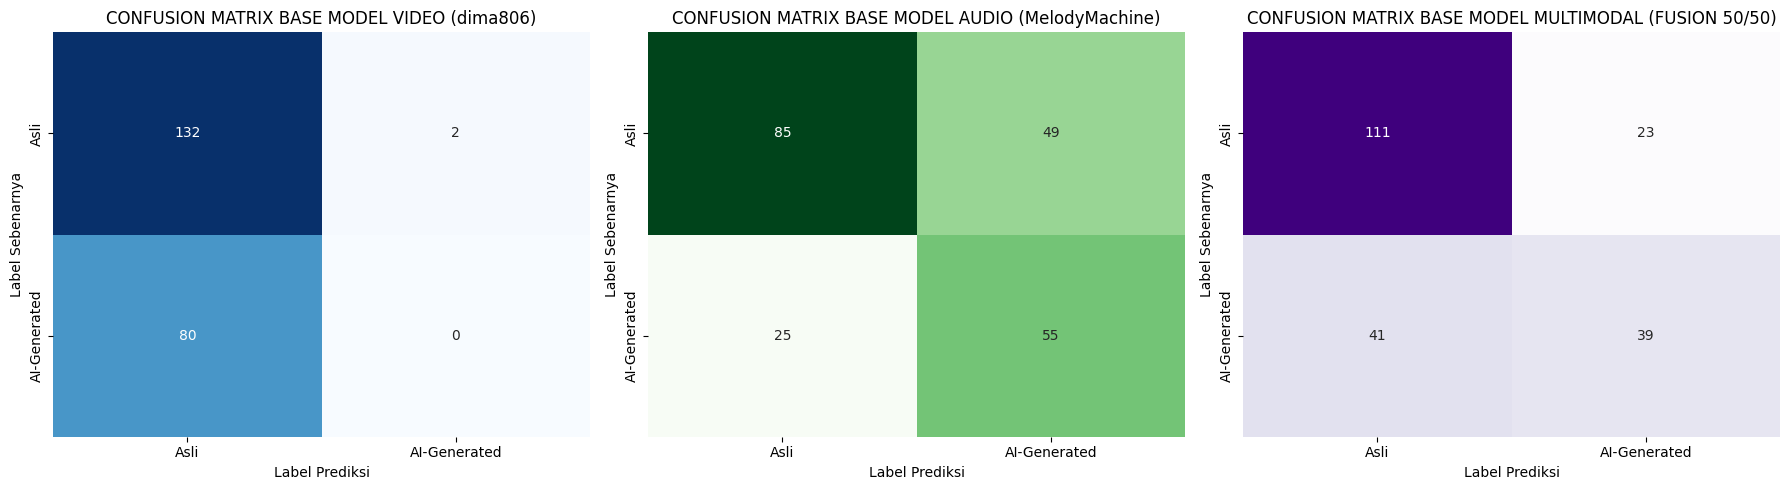


📋 DETAIL PRESISI & RECALL PER KELAS (Asli / AI-Generated)
▶ Video Saja       | Asli: Presisi 62.26% Recall 98.51% | AI-Generated: Presisi 0.00% Recall 0.00%
▶ Audio Saja       | Asli: Presisi 77.27% Recall 63.43% | AI-Generated: Presisi 52.88% Recall 68.75%
▶ Multimodal 50/50 | Asli: Presisi 73.03% Recall 82.84% | AI-Generated: Presisi 62.90% Recall 48.75%

📉 ANALISIS THRESHOLD MODEL VIDEO (BASE ZERO-SHOT)
Model card dima806: model Real-bias; author menyarankan threshold fake 0.1-0.01.
Threshold AI     Akurasi  AI Recall  Real Recall  #Pred AI
------------------------------------------------------------
0.50              61.68%      0.00%       98.51%         2
0.20              57.94%      1.25%       91.79%        12
0.10              51.40%      1.25%       81.34%        26
0.05              45.33%      3.75%       70.15%        43
0.01              34.58%     18.75%       44.03%        90

📊 PRETRAINED BASE MODEL ZERO-SHOT EVALUATION SUMMARY (FOLD-1 VAL SPLIT)


,Model,Accuracy,Precision (Macro),Recall (Macro),F1-Score (Macro)
0,Raw Video ViT (dima806),61.68%,31.13%,49.25%,38.15%
1,Raw Audio Wav2Vec2 (MelodyMachine - Corrected ...,65.42%,65.08%,66.09%,64.73%
2,Raw Multimodal Ensemble (Late Fusion),70.09%,67.96%,65.79%,66.28%


In [ ]:
# 8. Perbandingan Hasil Setiap Modalitas vs Multimodal (Base Model Zero-Shot)
print("=" * 80)
print("📊 PERBANDINGAN HASIL PER MODALITAS (BASE MODEL ZERO-SHOT)")
print("=" * 80)

modalities = {
    "Video Saja": val_video_base_preds,
    "Audio Saja": val_audio_base_preds,
    "Multimodal 50/50": val_fusion_base_preds,
}
for name, preds in modalities.items():
    acc = accuracy_score(val_targets, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(val_targets, preds, average="macro", zero_division=0)
    print(f"✅ {name:<16} | Akurasi: {acc*100:.2f}% | Presisi: {prec*100:.2f}% | Recall: {rec*100:.2f}% | F1: {f1*100:.2f}%")
print("=" * 80)

# Confusion Matrices Berdampingan (label Bahasa Indonesia)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles = {
    "Video Saja": "CONFUSION MATRIX BASE MODEL VIDEO (dima806)",
    "Audio Saja": "CONFUSION MATRIX BASE MODEL AUDIO (MelodyMachine)",
    "Multimodal 50/50": "CONFUSION MATRIX BASE MODEL MULTIMODAL (FUSION 50/50)",
}
cmaps = ["Blues", "Greens", "Purples"]
for ax, (name, preds), cmap in zip(axes, modalities.items(), cmaps):
    cm = confusion_matrix(val_targets, preds, labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap, cbar=False, ax=ax,
                xticklabels=DISPLAY_LABELS, yticklabels=DISPLAY_LABELS)
    ax.set_title(titles[name])
    ax.set_xlabel("Label Prediksi")
    ax.set_ylabel("Label Sebenarnya")
plt.tight_layout()
plt.show()

# Detail Presisi & Recall per Kelas
print("\n" + "=" * 80)
print("📋 DETAIL PRESISI & RECALL PER KELAS (Asli / AI-Generated)")
print("=" * 80)
for name, preds in modalities.items():
    prec, rec, _, _ = precision_recall_fscore_support(val_targets, preds, labels=[0, 1], zero_division=0)
    print(f"▶ {name:<16} | Asli: Presisi {prec[0]*100:.2f}% Recall {rec[0]*100:.2f}% | AI-Generated: Presisi {prec[1]*100:.2f}% Recall {rec[1]*100:.2f}%")


# 🎯 Analisis Threshold Video (rekomendasi penulis dima806: turunkan threshold fake ke 0.1 atau 0.01)
print("\n" + "=" * 80)
print("📉 ANALISIS THRESHOLD MODEL VIDEO (BASE ZERO-SHOT)")
print("=" * 80)
print("Model card dima806: model Real-bias; author menyarankan threshold fake 0.1-0.01.")
print(f"{'Threshold AI':<14} {'Akurasi':>9} {'AI Recall':>10} {'Real Recall':>12} {'#Pred AI':>9}")
print('-' * 60)
p_ai_vec = np.array([p[1] for p in val_video_base_probs])
for thr in [0.5, 0.2, 0.1, 0.05, 0.01]:
    preds_thr = [1 if p >= thr else 0 for p in p_ai_vec]
    acc = accuracy_score(val_targets, preds_thr)
    _, rec, _, _ = precision_recall_fscore_support(val_targets, preds_thr, labels=[0, 1], zero_division=0)
    print(f'{thr:<14.2f} {acc*100:>8.2f}% {rec[1]*100:>9.2f}% {rec[0]*100:>11.2f}% {sum(preds_thr):>9d}')
# Tabel ringkasan (dataframe)
def compute_metrics(y_true, y_pred, name="Model"):
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    return {
        "Model": name,
        "Accuracy": f"{acc * 100:.2f}%",
        "Precision (Macro)": f"{prec * 100:.2f}%",
        "Recall (Macro)": f"{rec * 100:.2f}%",
        "F1-Score (Macro)": f"{f1 * 100:.2f}%"
    }

results = [
    compute_metrics(val_targets, val_video_base_preds, "Raw Video ViT (dima806)"),
    compute_metrics(val_targets, val_audio_base_preds, "Raw Audio Wav2Vec2 (MelodyMachine - Corrected Mapping)"),
    compute_metrics(val_targets, val_fusion_base_preds, "Raw Multimodal Ensemble (Late Fusion)")
]

df_metrics = pd.DataFrame(results)
print("\n========================================================")
print("📊 PRETRAINED BASE MODEL ZERO-SHOT EVALUATION SUMMARY (FOLD-1 VAL SPLIT)")
print("========================================================")
display(df_metrics)


## 9. Single Video Zero-Shot Inference Demo

In [ ]:
def predict_base_multimodal_video(video_path, w_video=0.5, w_audio=0.5):
    """
    Zero-shot inference helper for single video using raw pretrained base models.
    """
    print(f"🎬 Zero-shot inspecting video: {video_path}")
    p_vid = predict_video_base_probs(video_path)
    p_aud = predict_audio_base_probs(video_path)
    p_fusion = (w_video * p_vid) + (w_audio * p_aud)
    
    pred_idx = int(np.argmax(p_fusion))
    pred_label = CLASSES[pred_idx]
    conf = float(p_fusion[pred_idx])
    
    print("--- Base Model Zero-Shot Scores ---")
    print(f"📹 ViT Base (dima806):        {CLASSES[np.argmax(p_vid)]} ({np.max(p_vid)*100:.2f}%)")
    print(f"🎙️ Wav2Vec2 Base (MelodyMachine): {CLASSES[np.argmax(p_aud)]} ({np.max(p_aud)*100:.2f}%)")
    print(f"🤝 COMBINED ZERO-SHOT RESULT:   {pred_label} ({conf*100:.2f}% confidence)")
    return pred_label, conf

# Example Usage:
# predict_base_multimodal_video("/content/dataset_raw_val/AI/sample_video.mp4")